In [1]:
import os
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path("..").resolve()

ACTIVITY_DIR = PROJECT_ROOT / "results" / "activity_analysis"
THERMAL_DIR  = PROJECT_ROOT / "results" / "thermal_modeling"

THERMAL_DIR.mkdir(parents=True, exist_ok=True)

# Load activity summary generated by Notebook 1
activity_summary_path = ACTIVITY_DIR / "activity_summary.csv"

if not activity_summary_path.exists():
    raise FileNotFoundError(
        f"Could not find activity summary file at: {activity_summary_path}\n"
        "Run Notebook 1 completely before starting Notebook 2."
    )

activity_df = pd.read_csv(activity_summary_path)

print("Project root :", PROJECT_ROOT)
print("Activity dir :", ACTIVITY_DIR)
print("Thermal dir  :", THERMAL_DIR)
print("Loaded activity summary from:", activity_summary_path)
print("Number of activity cases:", len(activity_df))

display(activity_df.head())

Project root : /home/aditya_chaudhry/thermal_aware_mac
Activity dir : /home/aditya_chaudhry/thermal_aware_mac/results/activity_analysis
Thermal dir  : /home/aditya_chaudhry/thermal_aware_mac/results/thermal_modeling
Loaded activity summary from: /home/aditya_chaudhry/thermal_aware_mac/results/activity_analysis/activity_summary.csv
Number of activity cases: 24


,architecture,workload,N,shape,sum_activity,max_activity,min_activity,mean_activity,std_activity,nonzero_cells
0,standard,checkerboard,2,2x2,20,10,0,5.0,5.000000,2
1,standard,hotspot,2,2x2,10,10,0,2.5,4.330127,1
2,standard,uniform,2,2x2,40,10,10,10.0,0.000000,4
3,standard,checkerboard,4,4x4,80,10,0,5.0,5.000000,8
4,standard,hotspot,4,4x4,40,10,0,2.5,4.330127,4


In [2]:
all_activity_matrices = {}

missing_files = []

for _, row in activity_df.iterrows():
    arch = row["architecture"]
    N = int(row["N"])
    workload = row["workload"]

    matrix_path = (
        ACTIVITY_DIR
        / arch
        / f"{N}x{N}"
        / workload
        / "activity_matrix.csv"
    )

    key = (arch, N, workload)

    if not matrix_path.exists():
        missing_files.append(str(matrix_path))
        continue

    mat = pd.read_csv(matrix_path).values

    # Sanity check
    if mat.shape != (N, N):
        raise ValueError(f"Shape mismatch for {key}: got {mat.shape}")

    all_activity_matrices[key] = mat

print("Loaded activity matrices:", len(all_activity_matrices))

if missing_files:
    print("\nMissing files:")
    for f in missing_files:
        print(f)

# Quick inspection
sample_key = list(all_activity_matrices.keys())[0]
print("\nSample key:", sample_key)
print("Sample matrix:\n", all_activity_matrices[sample_key])

Loaded activity matrices: 24

Sample key: ('standard', 2, 'checkerboard')
Sample matrix:
 [[10  0]
 [ 0 10]]


In [4]:
# ----------------------------------
# Thermal model parameters
# ----------------------------------
T_AMB = 25.0      # ambient/base temperature
ALPHA = 0.15      # diffusion strength
BETA  = 0.08      # activity -> heating scale
GAMMA = 0.02      # cooling-to-ambient factor
N_STEPS = 200     # number of simulation steps

print("Thermal parameters:")
print(f"T_AMB  = {T_AMB}")
print(f"ALPHA  = {ALPHA}")
print(f"BETA   = {BETA}")
print(f"GAMMA  = {GAMMA}")
print(f"N_STEPS = {N_STEPS}")


def activity_to_heat_normalized(activity_matrix):
    """
    Normalize activity matrix to [0, 1] based on its own max value.
    Good for comparing spatial patterns independent of absolute scale.
    """
    activity_matrix = np.asarray(activity_matrix, dtype=np.float32)
    max_val = np.max(activity_matrix)

    if max_val <= 0:
        return np.zeros_like(activity_matrix, dtype=np.float32)

    return activity_matrix / max_val


def activity_to_heat_absolute(activity_matrix, scale=0.1):
    """
    Convert activity matrix to absolute heat source using a linear scale.
    Good for preserving differences in total activity across architectures/sizes.
    """
    activity_matrix = np.asarray(activity_matrix, dtype=np.float32)
    return scale * activity_matrix


# Quick sanity check on one sample
sample_key = ("standard", 8, "checkerboard")
sample_activity = all_activity_matrices[sample_key]

Q_norm = activity_to_heat_normalized(sample_activity)
Q_abs  = activity_to_heat_absolute(sample_activity, scale=0.1)

print("\nSample activity matrix:")
print(sample_activity)

print("\nNormalized heat source Q_norm:")
print(Q_norm)

print("\nAbsolute heat source Q_abs:")
print(Q_abs)

Thermal parameters:
T_AMB  = 25.0
ALPHA  = 0.15
BETA   = 0.08
GAMMA  = 0.02
N_STEPS = 200

Sample activity matrix:
[[10  0 10  0 10  0 10  0]
 [ 0 10  0 10  0 10  0 10]
 [10  0 10  0 10  0 10  0]
 [ 0 10  0 10  0 10  0 10]
 [10  0 10  0 10  0 10  0]
 [ 0 10  0 10  0 10  0 10]
 [10  0 10  0 10  0 10  0]
 [ 0 10  0 10  0 10  0 10]]

Normalized heat source Q_norm:
[[1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1. 0. 1.]]

Absolute heat source Q_abs:
[[1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 1. 0. 1. 0. 1. 0. 1.]]


In [5]:
def laplacian_2d(T):
    """
    2D discrete Laplacian with edge padding (zero-flux / Neumann-like behavior).
    """
    T = np.asarray(T, dtype=np.float32)

    T_up    = np.roll(T, -1, axis=0)
    T_down  = np.roll(T,  1, axis=0)
    T_left  = np.roll(T, -1, axis=1)
    T_right = np.roll(T,  1, axis=1)

    # Neumann-like boundary handling: copy edge values
    T_up[-1, :]    = T[-1, :]
    T_down[0, :]   = T[0, :]
    T_left[:, -1]  = T[:, -1]
    T_right[:, 0]  = T[:, 0]

    return T_up + T_down + T_left + T_right - 4.0 * T


def thermal_step(T, Q, alpha=ALPHA, beta=BETA, gamma=GAMMA, Tamb=T_AMB):
    """
    One explicit thermal update step:
        T_next = T + alpha * Laplacian(T) + beta * Q - gamma * (T - Tamb)
    """
    T = np.asarray(T, dtype=np.float32)
    Q = np.asarray(Q, dtype=np.float32)

    lap = laplacian_2d(T)
    T_next = T + alpha * lap + beta * Q - gamma * (T - Tamb)

    return T_next.astype(np.float32)


def run_thermal_sim(Q, steps=N_STEPS, T0=None, alpha=ALPHA, beta=BETA, gamma=GAMMA, Tamb=T_AMB):
    """
    Run thermal simulation for a fixed heat source Q over 'steps' iterations.

    Returns:
        T_hist : array of shape (steps+1, N, N)
    """
    Q = np.asarray(Q, dtype=np.float32)

    if T0 is None:
        T = np.full_like(Q, Tamb, dtype=np.float32)
    else:
        T = np.asarray(T0, dtype=np.float32).copy()

    history = [T.copy()]

    for _ in range(steps):
        T = thermal_step(T, Q, alpha=alpha, beta=beta, gamma=gamma, Tamb=Tamb)
        history.append(T.copy())

    return np.array(history, dtype=np.float32)


# Quick sanity check using the sample Q_abs
sample_T_hist = run_thermal_sim(Q_abs, steps=20)

print("Thermal history shape:", sample_T_hist.shape)
print("Initial temperature map:")
print(sample_T_hist[0])

print("\nFinal temperature map after 20 steps:")
print(sample_T_hist[-1])

print("\nFinal max temperature:", float(np.max(sample_T_hist[-1])))
print("Final min temperature:", float(np.min(sample_T_hist[-1])))
print("Final avg temperature:", float(np.mean(sample_T_hist[-1])))

Thermal history shape: (21, 8, 8)
Initial temperature map:
[[25. 25. 25. 25. 25. 25. 25. 25.]
 [25. 25. 25. 25. 25. 25. 25. 25.]
 [25. 25. 25. 25. 25. 25. 25. 25.]
 [25. 25. 25. 25. 25. 25. 25. 25.]
 [25. 25. 25. 25. 25. 25. 25. 25.]
 [25. 25. 25. 25. 25. 25. 25. 25.]
 [25. 25. 25. 25. 25. 25. 25. 25.]
 [25. 25. 25. 25. 25. 25. 25. 25.]]

Final temperature map after 20 steps:
[[25.764729 25.640293 25.71906  25.620928 25.708641 25.610504 25.689268
  25.564833]
 [25.640295 25.70419  25.638899 25.696707 25.63286  25.690668 25.625374
  25.689268]
 [25.71906  25.6389   25.700802 25.632397 25.697172 25.628767 25.690668
  25.610504]
 [25.620928 25.696707 25.632397 25.697678 25.63189  25.697172 25.632862
  25.70864 ]
 [25.70864  25.63286  25.697174 25.631891 25.697676 25.632395 25.696707
  25.620928]
 [25.610504 25.690666 25.628767 25.697172 25.632395 25.7008   25.6389
  25.71906 ]
 [25.689268 25.625374 25.690666 25.63286  25.696705 25.638899 25.704191
  25.640297]
 [25.564837 25.689268 25.610

Sample key: ('standard', 8, 'checkerboard')
Q shape: (8, 8)
T_hist shape: (51, 8, 8)

Final max temperature: 26.380239486694336
Final min temperature: 26.163076400756836
Final avg temperature: 26.27165985107422


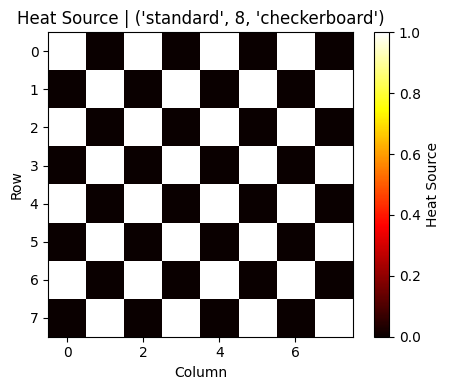

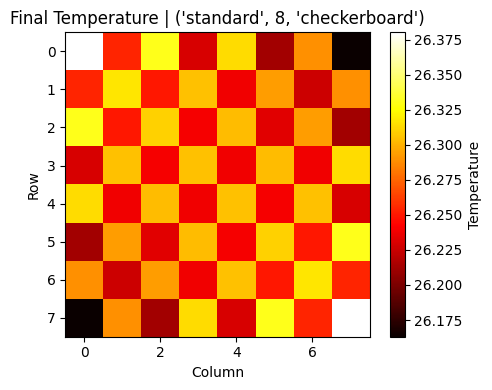

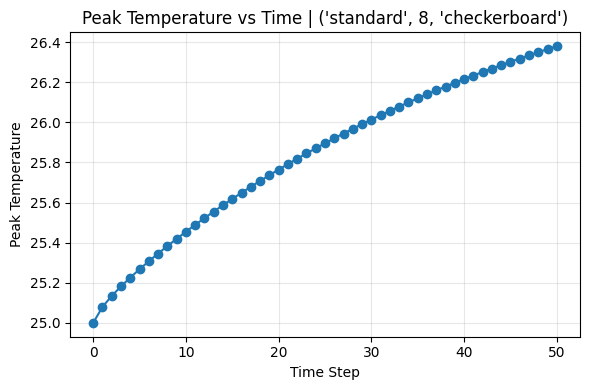

In [6]:
def plot_heat_source(Q, title="Heat Source Q"):
    plt.figure(figsize=(5, 4))
    im = plt.imshow(Q, interpolation="nearest", cmap="hot")
    plt.colorbar(im, label="Heat Source")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.tight_layout()
    plt.show()


def plot_temperature_map(T, title="Temperature Map"):
    plt.figure(figsize=(5, 4))
    im = plt.imshow(T, interpolation="nearest", cmap="hot")
    plt.colorbar(im, label="Temperature")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.tight_layout()
    plt.show()


def plot_peak_temp_over_time(T_hist, title="Peak Temperature vs Time"):
    peak_trace = [np.max(T) for T in T_hist]

    plt.figure(figsize=(6, 4))
    plt.plot(peak_trace, marker="o")
    plt.title(title)
    plt.xlabel("Time Step")
    plt.ylabel("Peak Temperature")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Pick a sample case explicitly
sample_key = ("standard", 8, "checkerboard")
sample_activity = all_activity_matrices[sample_key]

# Use absolute heat mapping for thermal simulation
sample_Q = activity_to_heat_absolute(sample_activity, scale=0.1)
sample_T_hist = run_thermal_sim(sample_Q, steps=50)

print("Sample key:", sample_key)
print("Q shape:", sample_Q.shape)
print("T_hist shape:", sample_T_hist.shape)

print("\nFinal max temperature:", float(np.max(sample_T_hist[-1])))
print("Final min temperature:", float(np.min(sample_T_hist[-1])))
print("Final avg temperature:", float(np.mean(sample_T_hist[-1])))

plot_heat_source(sample_Q, title=f"Heat Source | {sample_key}")
plot_temperature_map(sample_T_hist[-1], title=f"Final Temperature | {sample_key}")
plot_peak_temp_over_time(sample_T_hist, title=f"Peak Temperature vs Time | {sample_key}")

In [7]:
all_thermal_histories = {}
all_final_temperature_maps = {}
thermal_summary_rows = []

# Use absolute heat mapping as the main thermal input
HEAT_SCALE = 0.1

for key, activity_matrix in all_activity_matrices.items():
    architecture, N, workload = key

    Q = activity_to_heat_absolute(activity_matrix, scale=HEAT_SCALE)
    T_hist = run_thermal_sim(Q, steps=N_STEPS)

    T_final = T_hist[-1]

    peak_temp = float(np.max(T_final))
    min_temp = float(np.min(T_final))
    avg_temp = float(np.mean(T_final))
    temp_gradient = peak_temp - min_temp

    all_thermal_histories[key] = T_hist
    all_final_temperature_maps[key] = T_final

    thermal_summary_rows.append({
        "architecture": architecture,
        "workload": workload,
        "N": N,
        "shape": f"{N}x{N}",
        "heat_scale": HEAT_SCALE,
        "peak_temp": peak_temp,
        "min_temp": min_temp,
        "avg_temp": avg_temp,
        "temp_gradient": temp_gradient,
    })

thermal_df = pd.DataFrame(thermal_summary_rows).sort_values(
    by=["architecture", "N", "workload"]
).reset_index(drop=True)

print("Processed thermal cases:", len(thermal_df))
display(thermal_df)

Processed thermal cases: 24


,architecture,workload,N,shape,heat_scale,peak_temp,min_temp,avg_temp,temp_gradient
0,standard,checkerboard,2,2x2,0.1,27.029341,26.900307,26.964825,0.129034
1,standard,hotspot,2,2x2,0.1,26.139668,25.889669,25.982412,0.249998
2,standard,uniform,2,2x2,0.1,28.929646,28.929646,28.929646,0.000000
3,standard,checkerboard,4,4x4,0.1,27.057747,26.871895,26.964821,0.185852
4,standard,hotspot,4,4x4,0.1,26.548048,25.683933,25.982414,0.864115
5,standard,uniform,4,4x4,0.1,28.929646,28.929646,28.929646,0.000000
6,standard,checkerboard,8,8x8,0.1,27.074678,26.854965,26.964821,0.219713
7,standard,hotspot,8,8x8,0.1,27.512306,25.287233,25.982410,2.225073
8,standard,uniform,8,8x8,0.1,28.929646,28.929646,28.929644,0.000000
9,standard,checkerboard,16,16x16,0.1,27.079296,26.850351,26.964821,0.228945


In [8]:
# Save summary CSV
thermal_summary_path = THERMAL_DIR / "thermal_summary.csv"
thermal_df.to_csv(thermal_summary_path, index=False)

# Save final temperature maps
final_maps_path = THERMAL_DIR / "final_temperature_maps.npy"
np.save(final_maps_path, all_final_temperature_maps, allow_pickle=True)

# Save full histories
histories_path = THERMAL_DIR / "thermal_histories.npy"
np.save(histories_path, all_thermal_histories, allow_pickle=True)

print("Saved thermal summary :", thermal_summary_path)
print("Saved final maps      :", final_maps_path)
print("Saved thermal histories:", histories_path)

Saved thermal summary : /home/aditya_chaudhry/thermal_aware_mac/results/thermal_modeling/thermal_summary.csv
Saved final maps      : /home/aditya_chaudhry/thermal_aware_mac/results/thermal_modeling/final_temperature_maps.npy
Saved thermal histories: /home/aditya_chaudhry/thermal_aware_mac/results/thermal_modeling/thermal_histories.npy


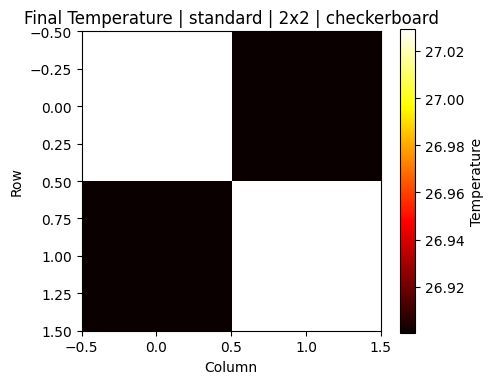

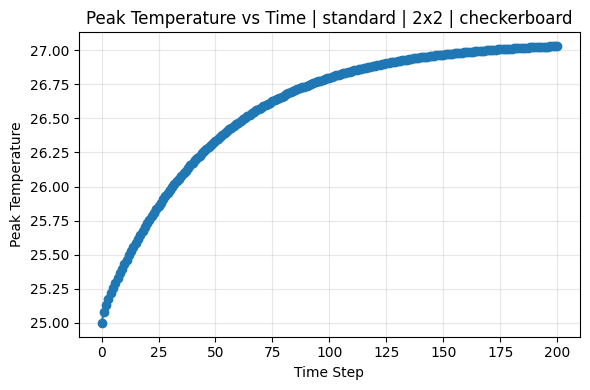

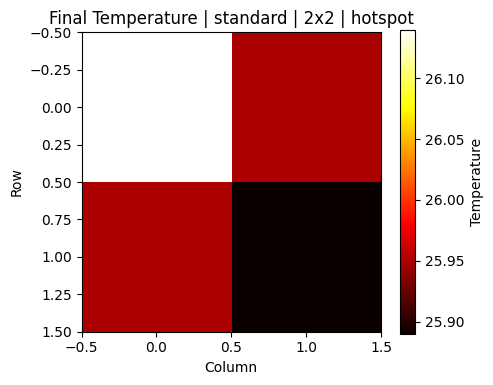

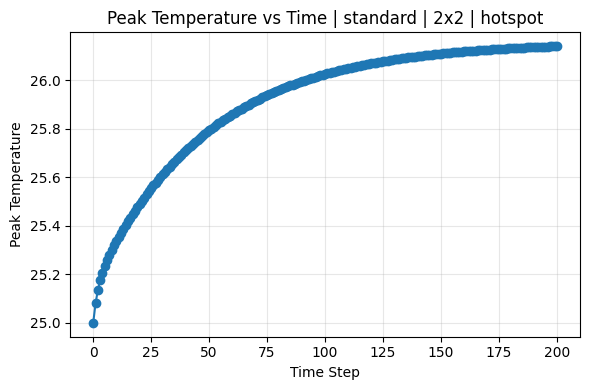

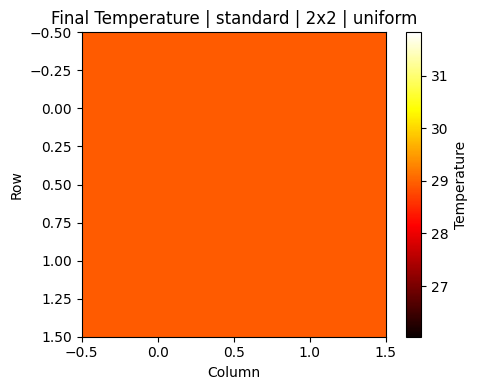

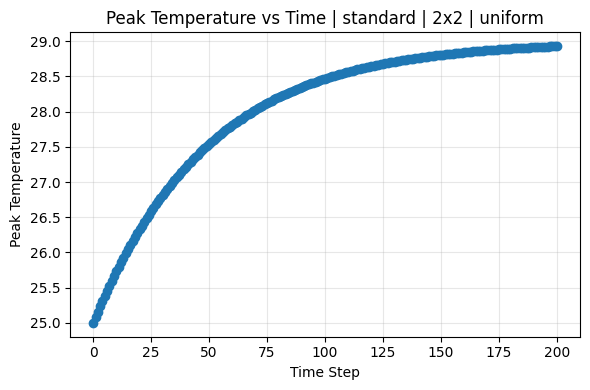

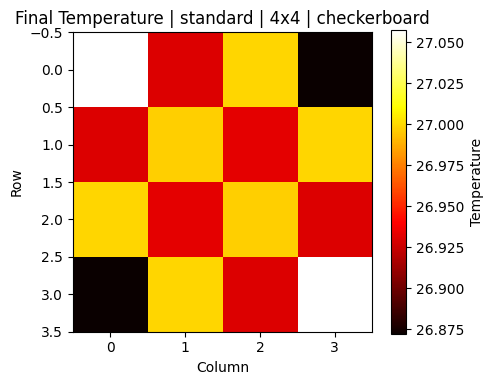

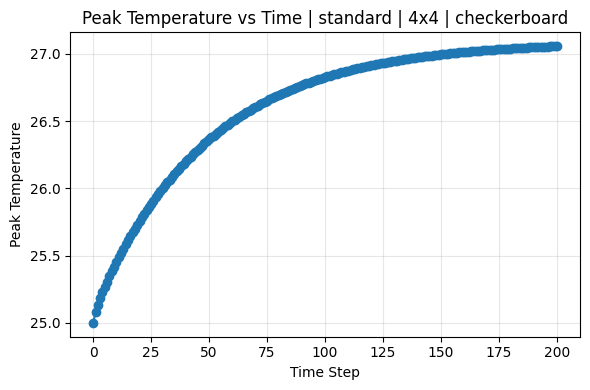

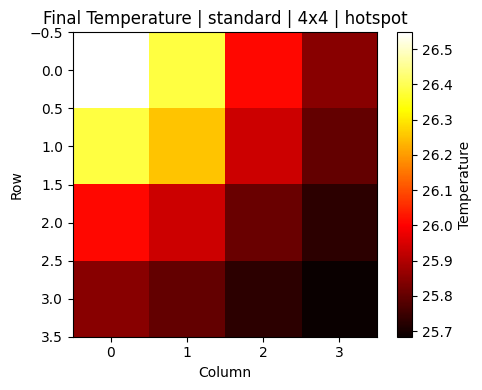

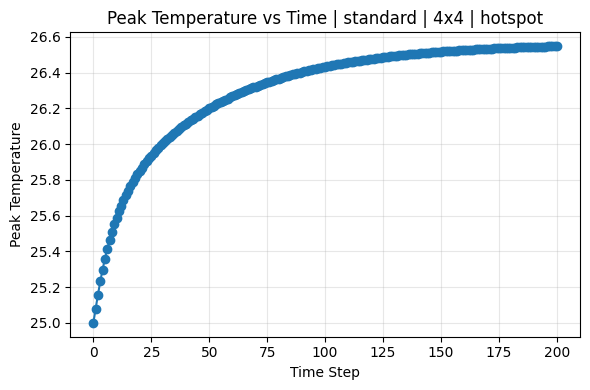

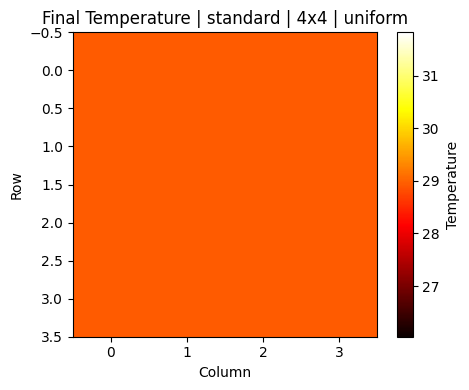

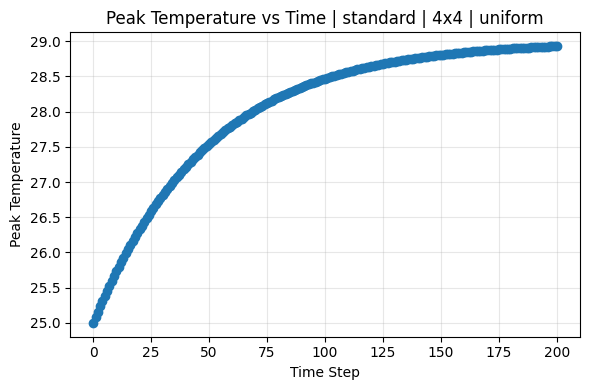

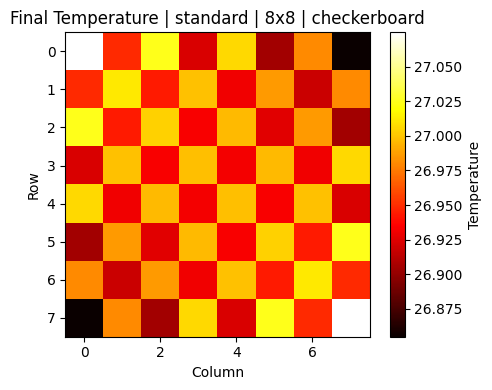

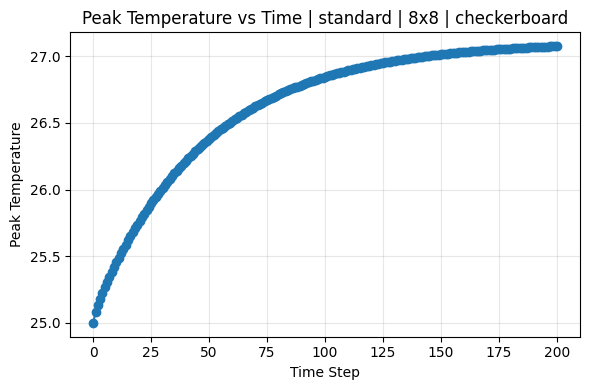

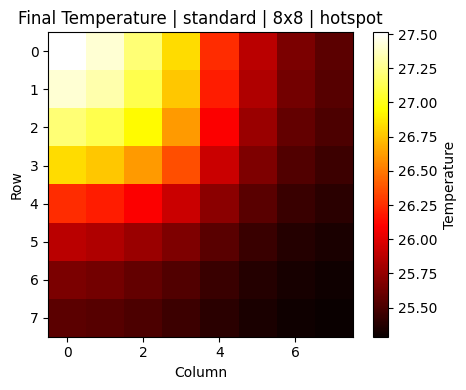

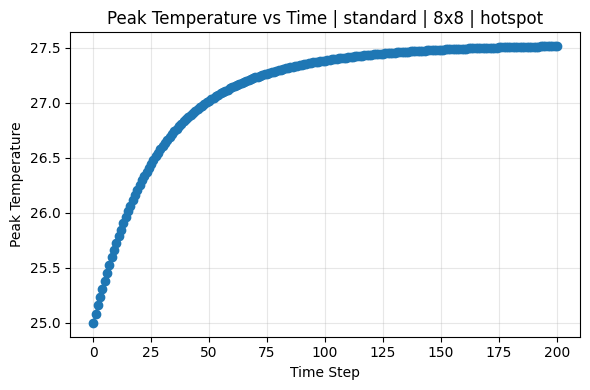

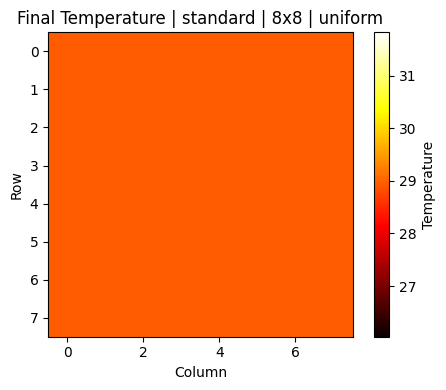

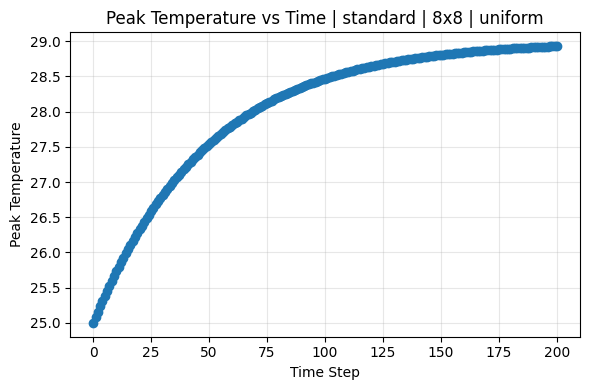

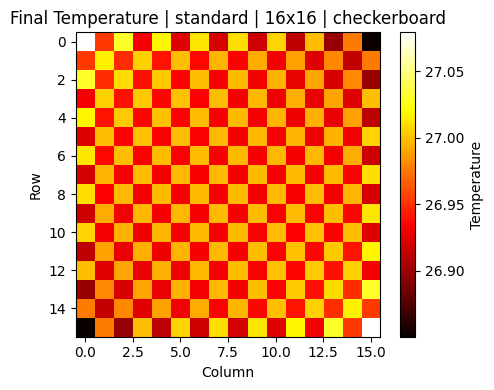

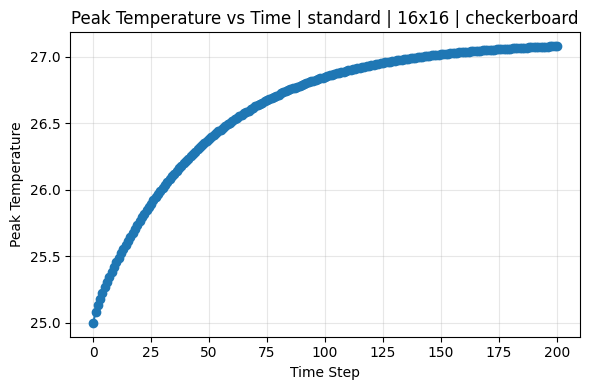

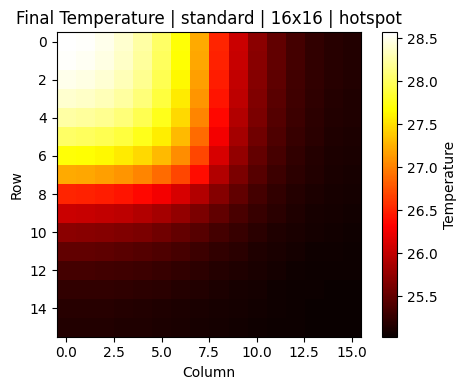

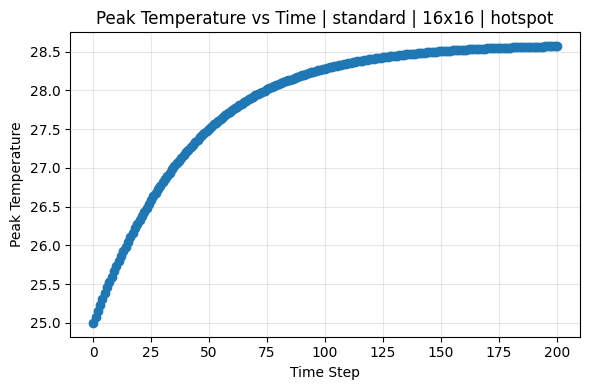

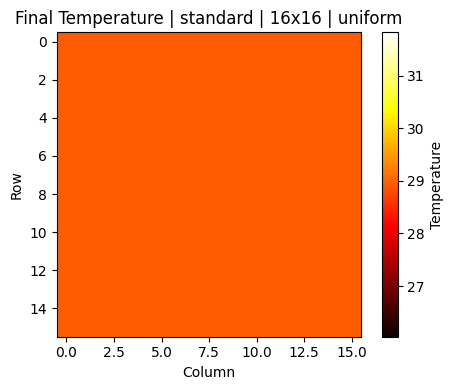

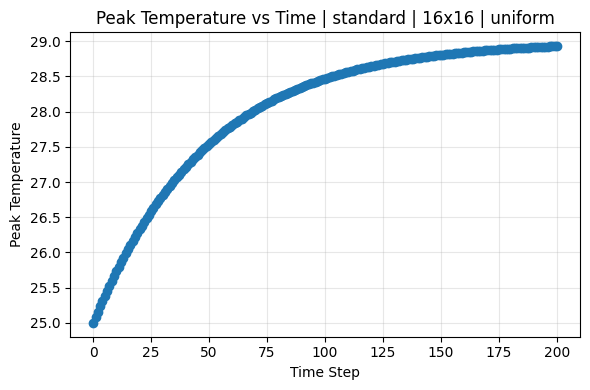

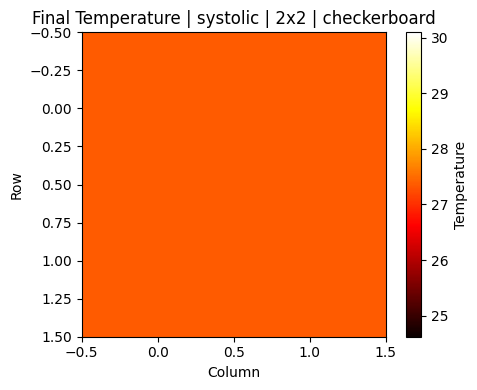

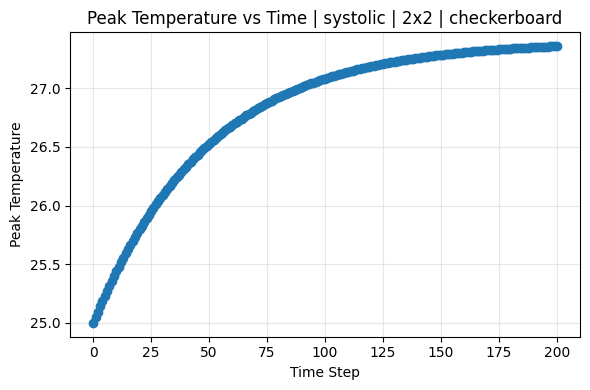

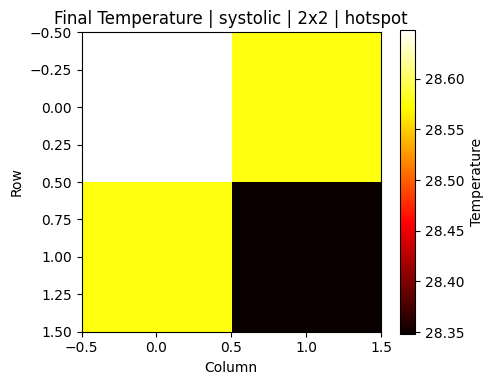

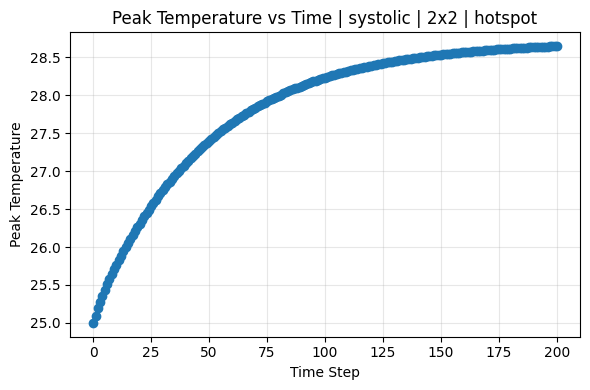

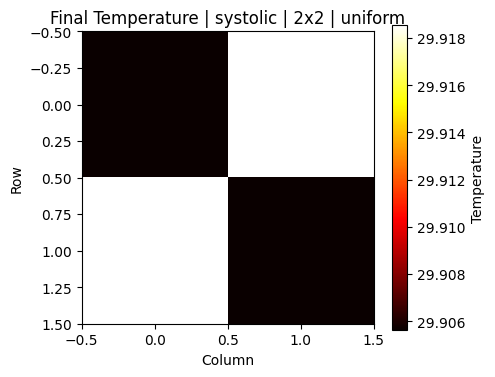

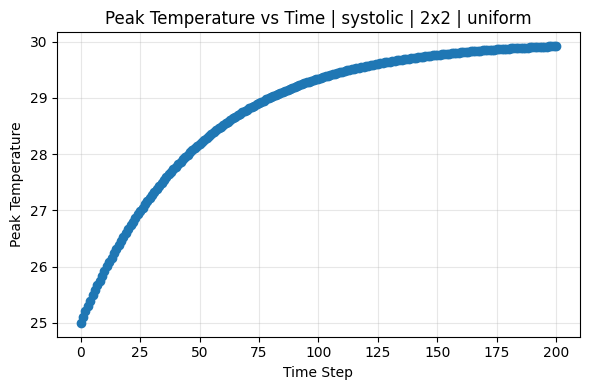

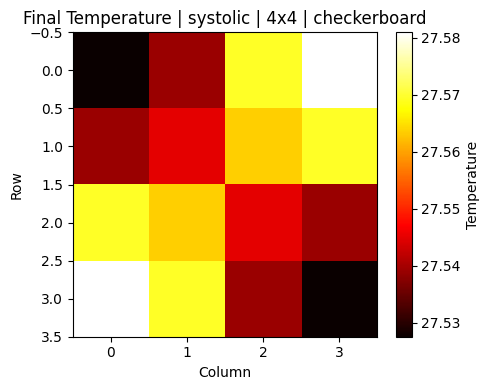

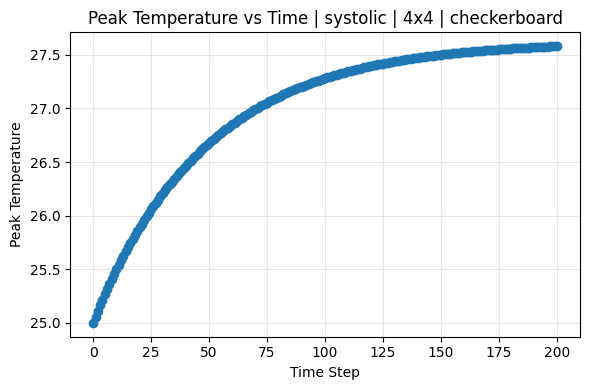

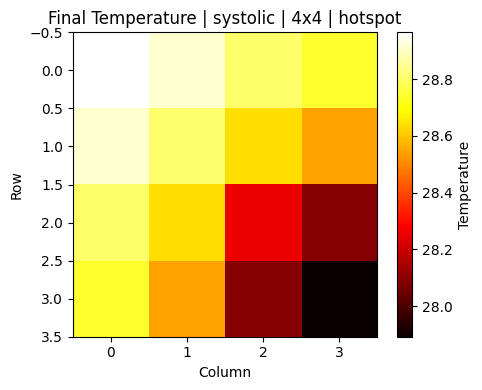

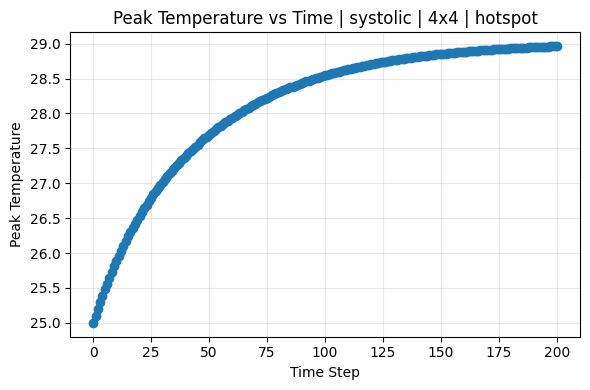

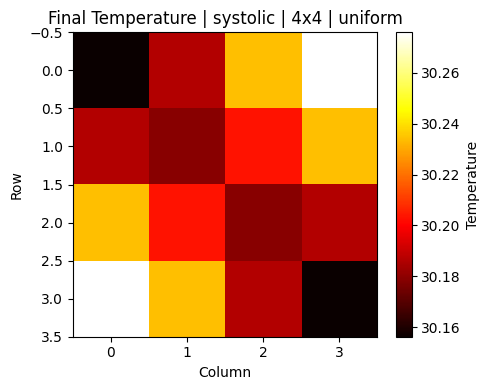

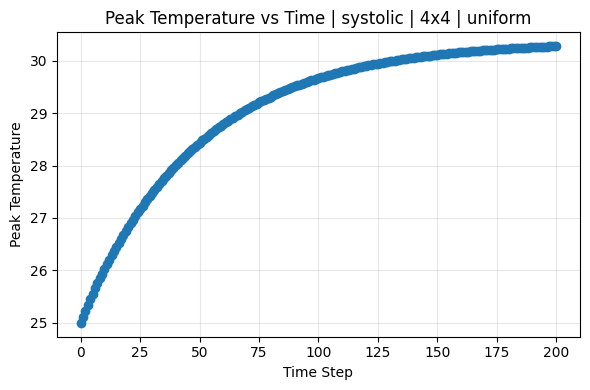

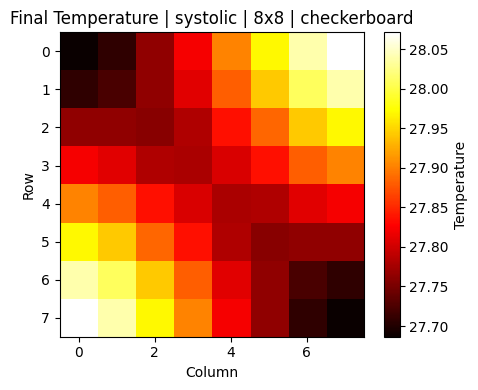

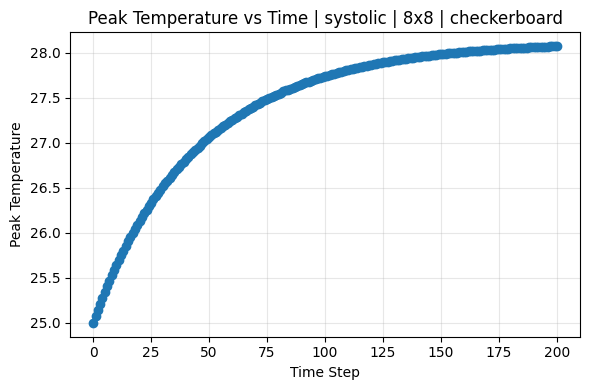

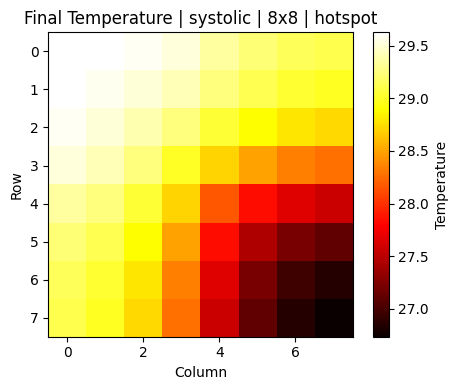

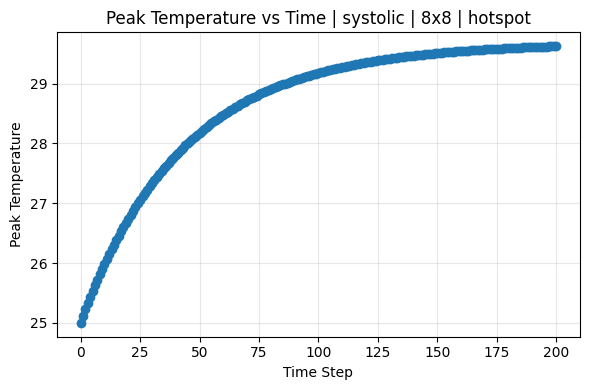

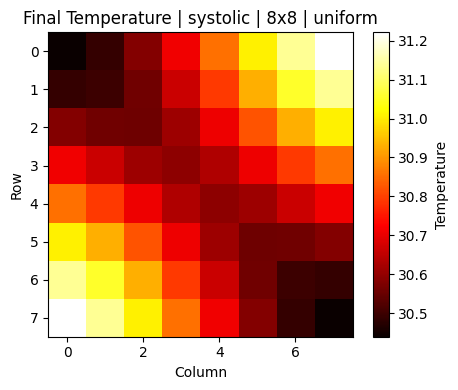

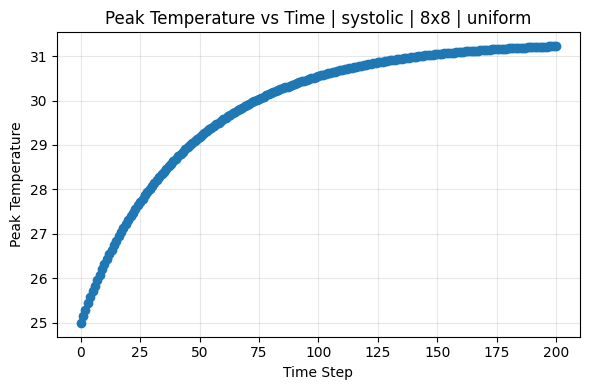

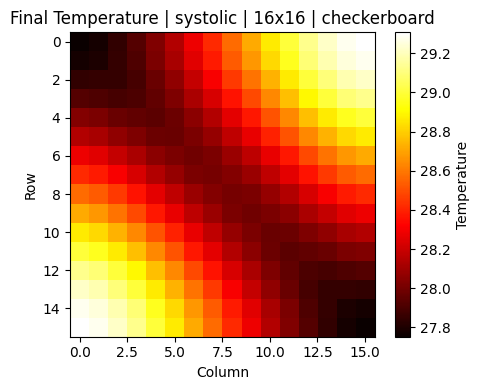

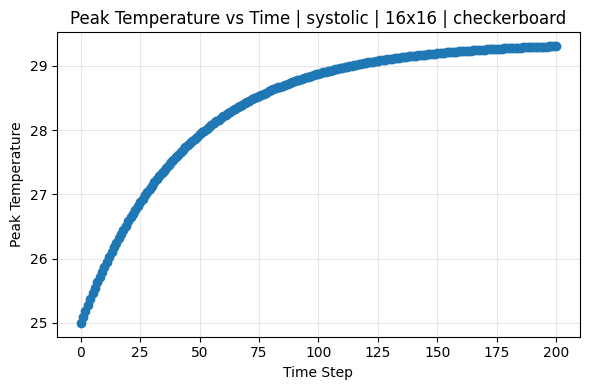

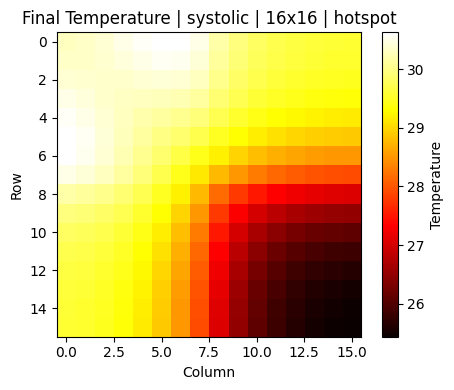

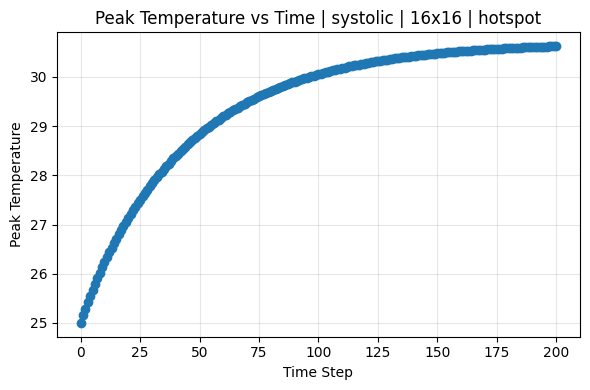

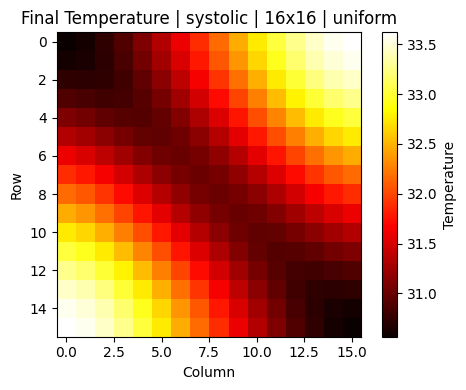

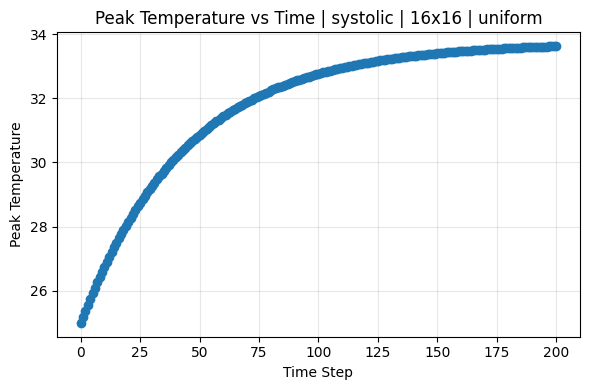

Saved all thermal maps, peak traces, and summaries.


In [9]:
def make_thermal_case_dir(base_dir, architecture, N, workload):
    case_dir = base_dir / architecture / f"{N}x{N}" / workload
    case_dir.mkdir(parents=True, exist_ok=True)
    return case_dir


def plot_temperature_heatmap(T, title, save_path=None, annotate=False, cmap="hot"):
    plt.figure(figsize=(5, 4))
    im = plt.imshow(T, interpolation="nearest", cmap=cmap)
    plt.colorbar(im, label="Temperature")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")

    if annotate:
        tmax = np.max(T)
        tmin = np.min(T)
        thresh = 0.5 * (tmax + tmin)

        for i in range(T.shape[0]):
            for j in range(T.shape[1]):
                val = T[i, j]
                color = "white" if val < thresh else "black"
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=7)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


def plot_peak_temp_trace(T_hist, title, save_path=None):
    peak_trace = [np.max(T) for T in T_hist]

    plt.figure(figsize=(6, 4))
    plt.plot(peak_trace, marker="o")
    plt.title(title)
    plt.xlabel("Time Step")
    plt.ylabel("Peak Temperature")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


# Save and plot all final thermal maps + peak traces
for _, row in thermal_df.iterrows():
    arch = row["architecture"]
    N = int(row["N"])
    workload = row["workload"]
    key = (arch, N, workload)

    case_dir = make_thermal_case_dir(THERMAL_DIR, arch, N, workload)

    T_final = all_final_temperature_maps[key]
    T_hist  = all_thermal_histories[key]

    # Save final temperature matrix
    pd.DataFrame(T_final).to_csv(case_dir / "final_temperature_map.csv", index=False)

    # Save summary json
    with open(case_dir / "thermal_summary.json", "w") as f:
        json.dump(
            {
                "architecture": arch,
                "workload": workload,
                "N": N,
                "shape": f"{N}x{N}",
                "heat_scale": float(row["heat_scale"]),
                "peak_temp": float(row["peak_temp"]),
                "min_temp": float(row["min_temp"]),
                "avg_temp": float(row["avg_temp"]),
                "temp_gradient": float(row["temp_gradient"]),
            },
            f,
            indent=2,
        )

    # Plot and save
    plot_temperature_heatmap(
        T_final,
        title=f"Final Temperature | {arch} | {N}x{N} | {workload}",
        save_path=case_dir / "final_temperature_map.png",
        annotate=False,
    )

    plot_peak_temp_trace(
        T_hist,
        title=f"Peak Temperature vs Time | {arch} | {N}x{N} | {workload}",
        save_path=case_dir / "peak_temp_trace.png",
    )

print("Saved all thermal maps, peak traces, and summaries.")

/tmp/ipykernel_93113/924885868.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


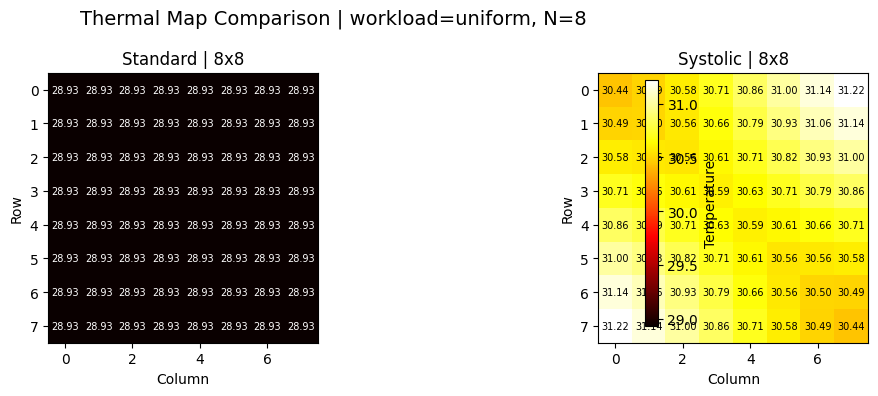

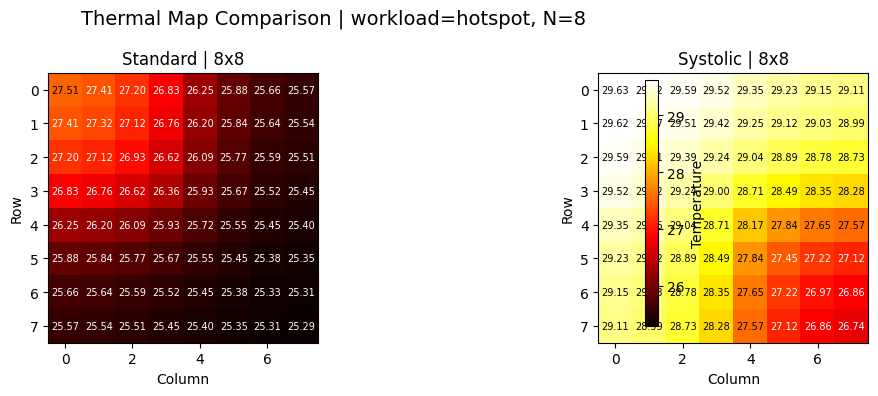

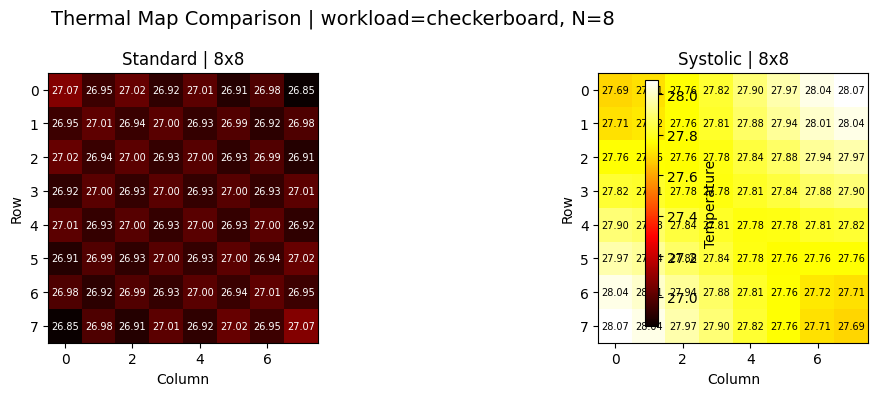

In [10]:
def plot_side_by_side_thermal_comparison(N, workload, annotate=False, cmap="hot"):
    key_std = ("standard", N, workload)
    key_sys = ("systolic", N, workload)

    if key_std not in all_final_temperature_maps or key_sys not in all_final_temperature_maps:
        print(f"Missing thermal maps for workload={workload}, N={N}")
        return

    T_std = all_final_temperature_maps[key_std]
    T_sys = all_final_temperature_maps[key_sys]

    vmin = min(np.min(T_std), np.min(T_sys))
    vmax = max(np.max(T_std), np.max(T_sys))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for ax, T, title in zip(
        axes,
        [T_std, T_sys],
        [f"Standard | {N}x{N}", f"Systolic | {N}x{N}"]
    ):
        im = ax.imshow(T, interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")

        if annotate:
            thresh = 0.5 * (vmin + vmax)
            for i in range(T.shape[0]):
                for j in range(T.shape[1]):
                    color = "white" if T[i, j] < thresh else "black"
                    ax.text(j, i, f"{T[i, j]:.2f}", ha="center", va="center", color=color, fontsize=7)

    fig.colorbar(im, ax=axes, shrink=0.8, label="Temperature")
    fig.suptitle(f"Thermal Map Comparison | workload={workload}, N={N}", fontsize=14)
    plt.tight_layout()
    plt.show()


# Good representative comparisons
plot_side_by_side_thermal_comparison(8, "uniform", annotate=True)
plot_side_by_side_thermal_comparison(8, "hotspot", annotate=True)
plot_side_by_side_thermal_comparison(8, "checkerboard", annotate=True)

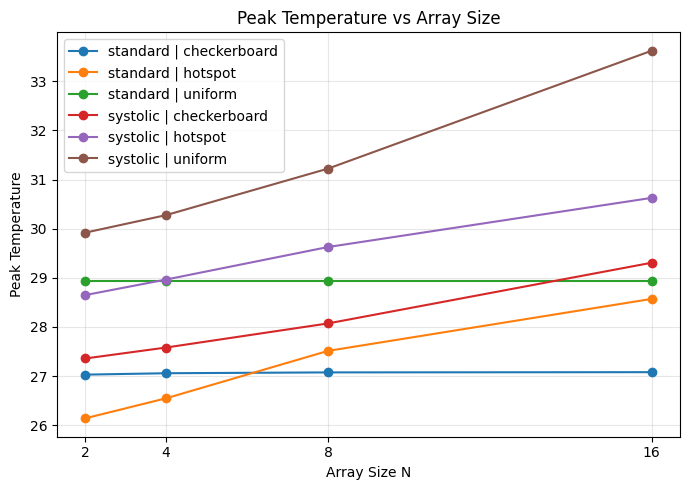

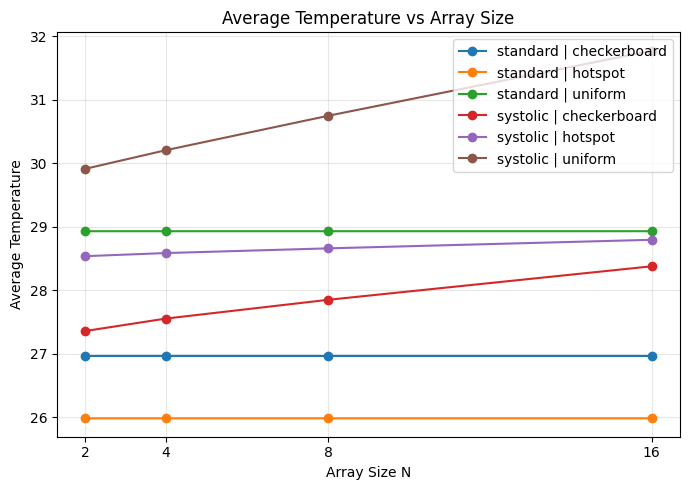

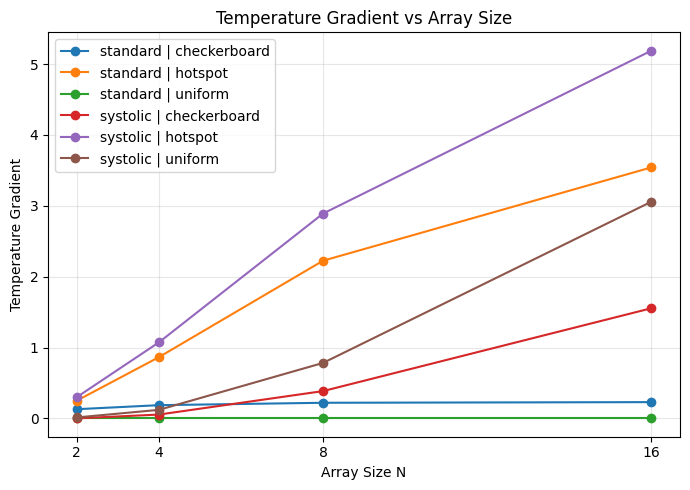

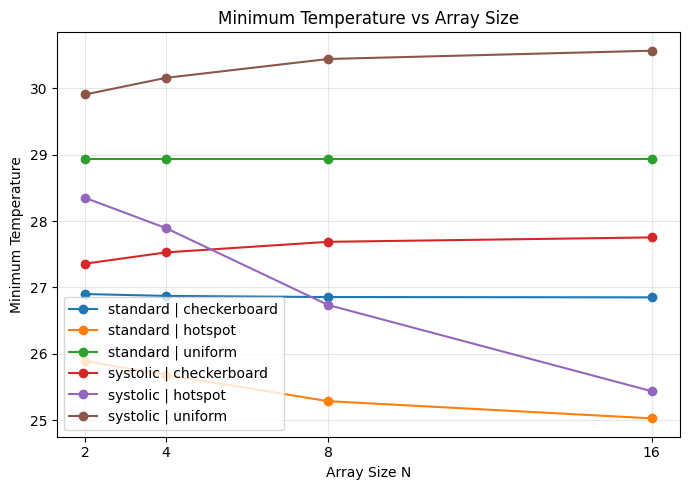

Saved thermal comparison plots to: /home/aditya_chaudhry/thermal_aware_mac/results/thermal_modeling/comparison_plots


In [11]:
thermal_plot_dir = THERMAL_DIR / "comparison_plots"
thermal_plot_dir.mkdir(parents=True, exist_ok=True)

thermal_plot_df = thermal_df.copy().sort_values(["architecture", "workload", "N"])


def save_thermal_line_plot(df, y_col, title, ylabel, filename):
    plt.figure(figsize=(7, 5))

    for arch in sorted(df["architecture"].unique()):
        for workload in sorted(df["workload"].unique()):
            sub = df[(df["architecture"] == arch) & (df["workload"] == workload)].sort_values("N")
            label = f"{arch} | {workload}"
            plt.plot(sub["N"], sub[y_col], marker="o", label=label)

    plt.title(title)
    plt.xlabel("Array Size N")
    plt.ylabel(ylabel)
    plt.xticks(sorted(df["N"].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(thermal_plot_dir / filename, dpi=200, bbox_inches="tight")
    plt.show()


save_thermal_line_plot(
    thermal_plot_df,
    y_col="peak_temp",
    title="Peak Temperature vs Array Size",
    ylabel="Peak Temperature",
    filename="peak_temp_vs_N.png"
)

save_thermal_line_plot(
    thermal_plot_df,
    y_col="avg_temp",
    title="Average Temperature vs Array Size",
    ylabel="Average Temperature",
    filename="avg_temp_vs_N.png"
)

save_thermal_line_plot(
    thermal_plot_df,
    y_col="temp_gradient",
    title="Temperature Gradient vs Array Size",
    ylabel="Temperature Gradient",
    filename="temp_gradient_vs_N.png"
)

save_thermal_line_plot(
    thermal_plot_df,
    y_col="min_temp",
    title="Minimum Temperature vs Array Size",
    ylabel="Minimum Temperature",
    filename="min_temp_vs_N.png"
)

print("Saved thermal comparison plots to:", thermal_plot_dir)

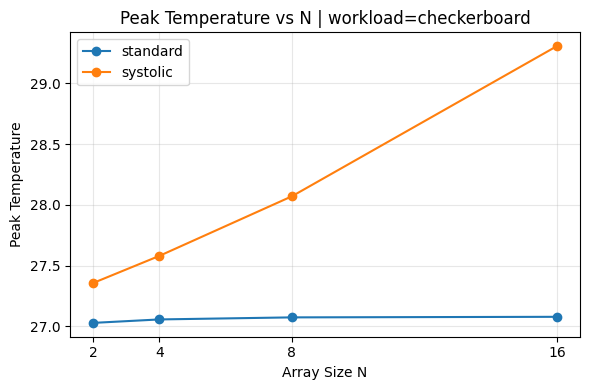

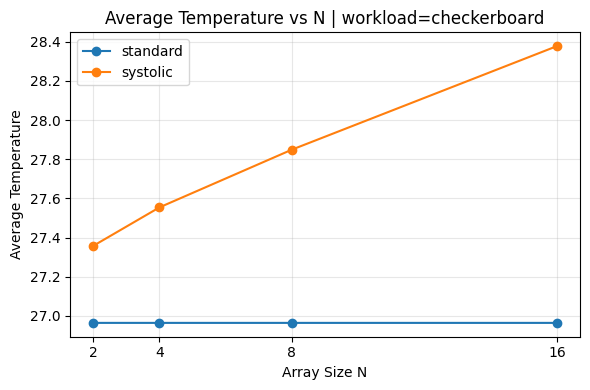

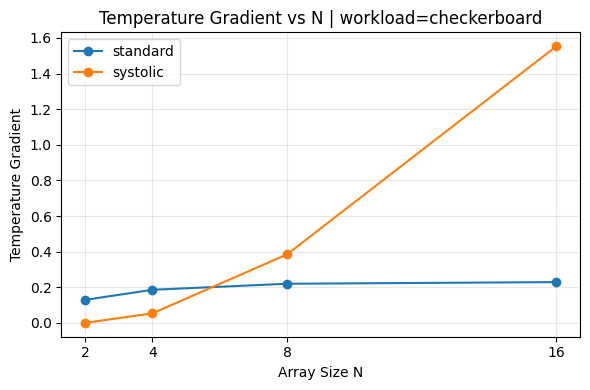

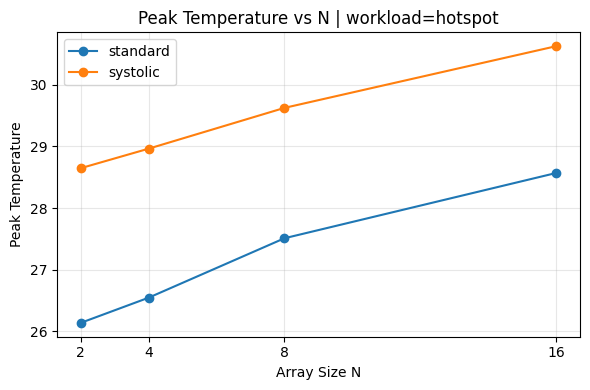

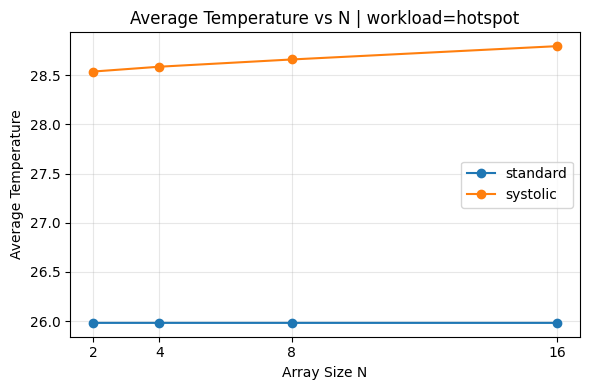

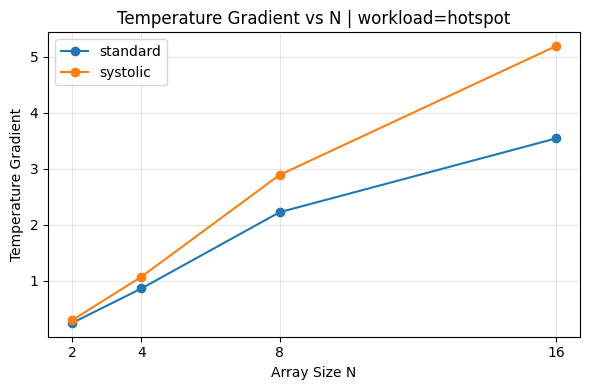

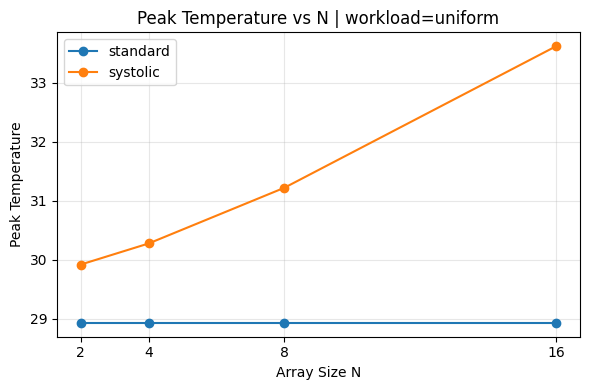

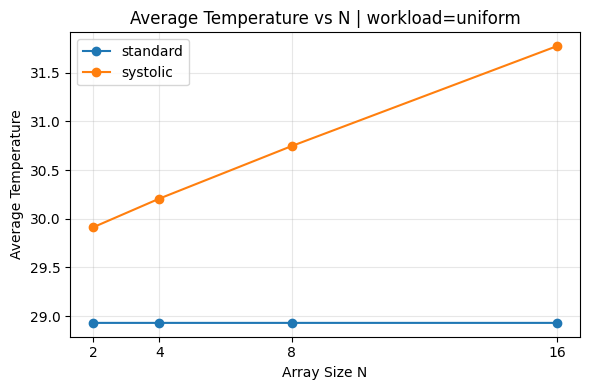

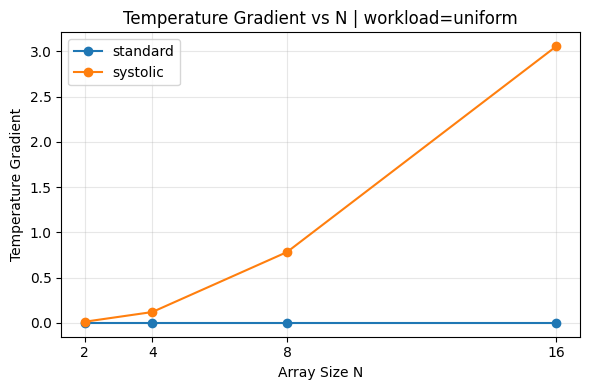

In [12]:
def architecture_thermal_comparison_plot(workload, metric, ylabel, filename_suffix):
    sub = thermal_plot_df[thermal_plot_df["workload"] == workload].sort_values(["architecture", "N"])

    plt.figure(figsize=(6, 4))

    for arch in sorted(sub["architecture"].unique()):
        arch_df = sub[sub["architecture"] == arch].sort_values("N")
        plt.plot(arch_df["N"], arch_df[metric], marker="o", label=arch)

    plt.title(f"{ylabel} vs N | workload={workload}")
    plt.xlabel("Array Size N")
    plt.ylabel(ylabel)
    plt.xticks(sorted(sub["N"].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(thermal_plot_dir / f"{metric}_{filename_suffix}_{workload}.png", dpi=200, bbox_inches="tight")
    plt.show()


for wl in sorted(thermal_plot_df["workload"].unique()):
    architecture_thermal_comparison_plot(wl, "peak_temp", "Peak Temperature", "arch_compare")
    architecture_thermal_comparison_plot(wl, "avg_temp", "Average Temperature", "arch_compare")
    architecture_thermal_comparison_plot(wl, "temp_gradient", "Temperature Gradient", "arch_compare")

In [13]:
# Make a copy so we keep the original clean
thermal_metrics_df = thermal_df.copy()

# Pull activity metrics from Notebook 1 summary
activity_metrics_lookup = activity_df.set_index(["architecture", "N", "workload"])

sum_activity_list = []
mean_activity_list = []
max_activity_list = []
std_activity_list = []
nonzero_cells_list = []

hotspot_fraction_list = []
hotspot_cells_list = []

HOTSPOT_REL_THRESH = 0.90  # cells >= 90% of peak temperature

for _, row in thermal_metrics_df.iterrows():
    key = (row["architecture"], int(row["N"]), row["workload"])

    # Activity-side metrics
    arow = activity_metrics_lookup.loc[key]
    sum_activity_list.append(float(arow["sum_activity"]))
    mean_activity_list.append(float(arow["mean_activity"]))
    max_activity_list.append(float(arow["max_activity"]))
    std_activity_list.append(float(arow["std_activity"]))
    nonzero_cells_list.append(float(arow["nonzero_cells"]))

    # Thermal-side derived metrics
    T_final = all_final_temperature_maps[key]
    peak_temp = float(np.max(T_final))
    thresh = HOTSPOT_REL_THRESH * peak_temp

    hotspot_cells = int(np.sum(T_final >= thresh))
    hotspot_fraction = hotspot_cells / T_final.size

    hotspot_cells_list.append(hotspot_cells)
    hotspot_fraction_list.append(hotspot_fraction)

thermal_metrics_df["sum_activity"] = sum_activity_list
thermal_metrics_df["mean_activity"] = mean_activity_list
thermal_metrics_df["max_activity"] = max_activity_list
thermal_metrics_df["std_activity"] = std_activity_list
thermal_metrics_df["nonzero_cells"] = nonzero_cells_list

thermal_metrics_df["thermal_efficiency"] = (
    thermal_metrics_df["sum_activity"] / thermal_metrics_df["peak_temp"]
)

thermal_metrics_df["grad_norm"] = (
    thermal_metrics_df["temp_gradient"] / thermal_metrics_df["avg_temp"]
)

thermal_metrics_df["hotspot_cells"] = hotspot_cells_list
thermal_metrics_df["hotspot_fraction"] = hotspot_fraction_list

display(thermal_metrics_df)

,architecture,workload,N,shape,heat_scale,peak_temp,min_temp,avg_temp,temp_gradient,sum_activity,mean_activity,max_activity,std_activity,nonzero_cells,thermal_efficiency,grad_norm,hotspot_cells,hotspot_fraction
0,standard,checkerboard,2,2x2,0.1,27.029341,26.900307,26.964825,0.129034,20.0,5.000000,10.0,5.000000,2.0,0.739937,0.004785,4,1.000000
1,standard,hotspot,2,2x2,0.1,26.139668,25.889669,25.982412,0.249998,10.0,2.500000,10.0,4.330127,1.0,0.382560,0.009622,4,1.000000
2,standard,uniform,2,2x2,0.1,28.929646,28.929646,28.929646,0.000000,40.0,10.000000,10.0,0.000000,4.0,1.382665,0.000000,4,1.000000
3,standard,checkerboard,4,4x4,0.1,27.057747,26.871895,26.964821,0.185852,80.0,5.000000,10.0,5.000000,8.0,2.956639,0.006892,16,1.000000
4,standard,hotspot,4,4x4,0.1,26.548048,25.683933,25.982414,0.864115,40.0,2.500000,10.0,4.330127,4.0,1.506702,0.033258,16,1.000000
5,standard,uniform,4,4x4,0.1,28.929646,28.929646,28.929646,0.000000,160.0,10.000000,10.0,0.000000,16.0,5.530659,0.000000,16,1.000000
6,standard,checkerboard,8,8x8,0.1,27.074678,26.854965,26.964821,0.219713,320.0,5.000000,10.0,5.000000,32.0,11.819162,0.008148,64,1.000000
7,standard,hotspot,8,8x8,0.1,27.512306,25.287233,25.982410,2.225073,160.0,2.500000,10.0,4.330127,16.0,5.815579,0.085638,64,1.000000
8,standard,uniform,8,8x8,0.1,28.929646,28.929646,28.929644,0.000000,640.0,10.000000,10.0,0.000000,64.0,22.122635,0.000000,64,1.000000
9,standard,checkerboard,16,16x16,0.1,27.079296,26.850351,26.964821,0.228945,1280.0,5.000000,10.0,5.000000,128.0,47.268585,0.008490,256,1.000000


In [14]:
thermal_metrics_path = THERMAL_DIR / "thermal_metrics_summary.csv"
thermal_metrics_df.to_csv(thermal_metrics_path, index=False)

print("Saved extended thermal metrics to:", thermal_metrics_path)

Saved extended thermal metrics to: /home/aditya_chaudhry/thermal_aware_mac/results/thermal_modeling/thermal_metrics_summary.csv


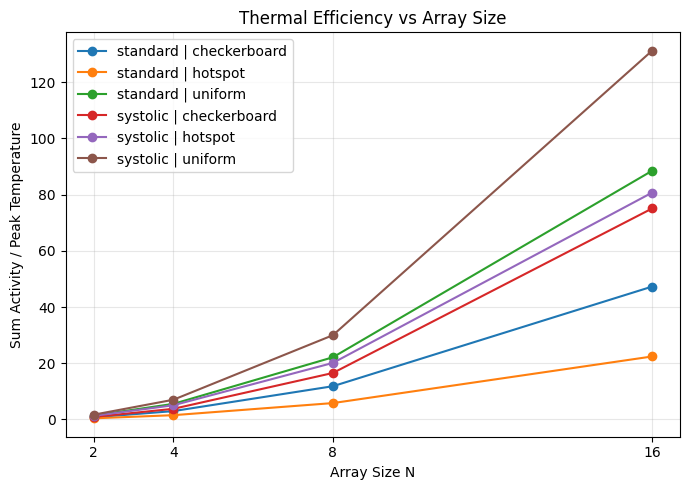

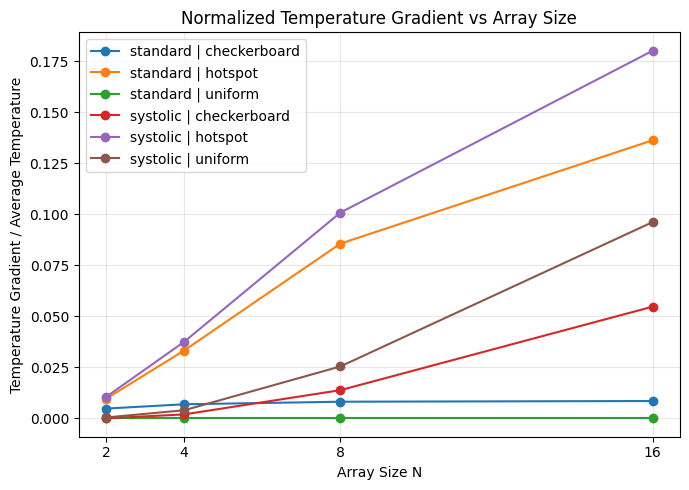

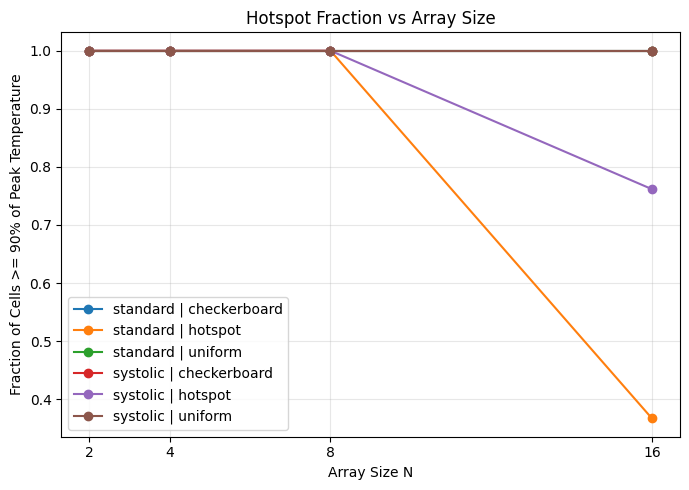

In [15]:
advanced_plot_dir = THERMAL_DIR / "advanced_metric_plots"
advanced_plot_dir.mkdir(parents=True, exist_ok=True)

def save_metric_plot(df, y_col, title, ylabel, filename):
    plt.figure(figsize=(7, 5))

    for arch in sorted(df["architecture"].unique()):
        for workload in sorted(df["workload"].unique()):
            sub = df[(df["architecture"] == arch) & (df["workload"] == workload)].sort_values("N")
            plt.plot(sub["N"], sub[y_col], marker="o", label=f"{arch} | {workload}")

    plt.title(title)
    plt.xlabel("Array Size N")
    plt.ylabel(ylabel)
    plt.xticks(sorted(df["N"].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(advanced_plot_dir / filename, dpi=200, bbox_inches="tight")
    plt.show()


save_metric_plot(
    thermal_metrics_df,
    "thermal_efficiency",
    "Thermal Efficiency vs Array Size",
    "Sum Activity / Peak Temperature",
    "thermal_efficiency_vs_N.png"
)

save_metric_plot(
    thermal_metrics_df,
    "grad_norm",
    "Normalized Temperature Gradient vs Array Size",
    "Temperature Gradient / Average Temperature",
    "normalized_gradient_vs_N.png"
)

save_metric_plot(
    thermal_metrics_df,
    "hotspot_fraction",
    "Hotspot Fraction vs Array Size",
    "Fraction of Cells >= 90% of Peak Temperature",
    "hotspot_fraction_vs_N.png"
)

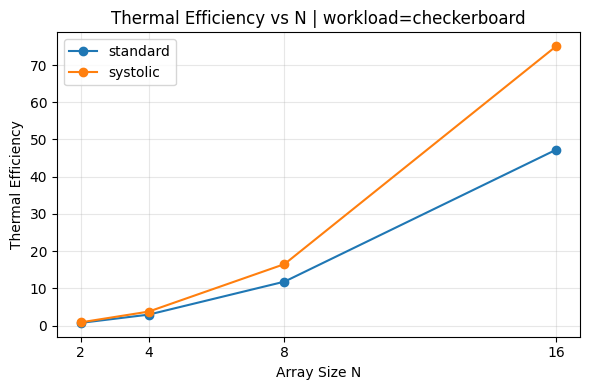

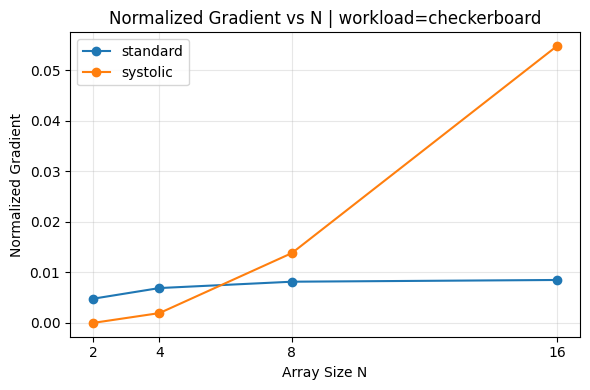

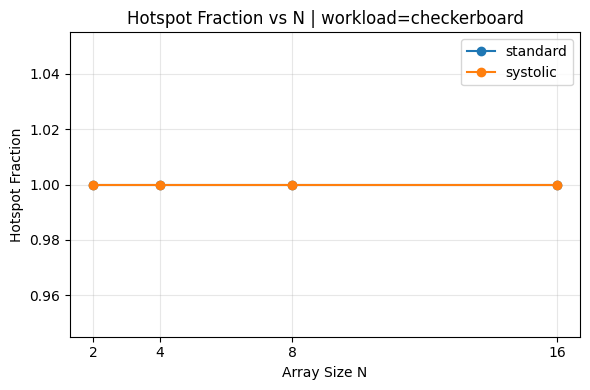

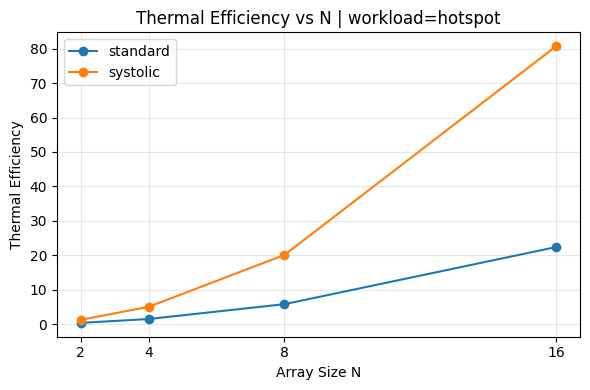

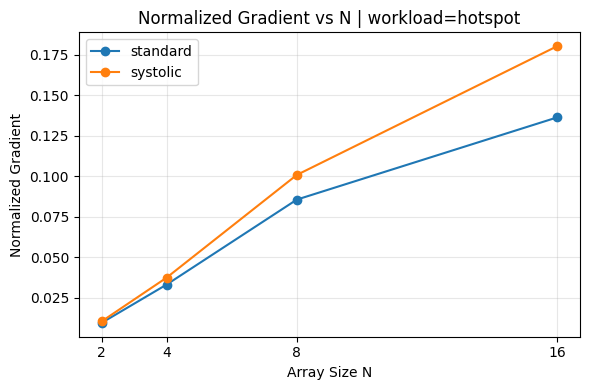

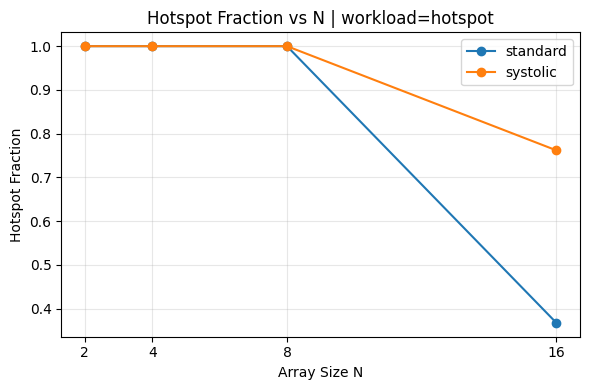

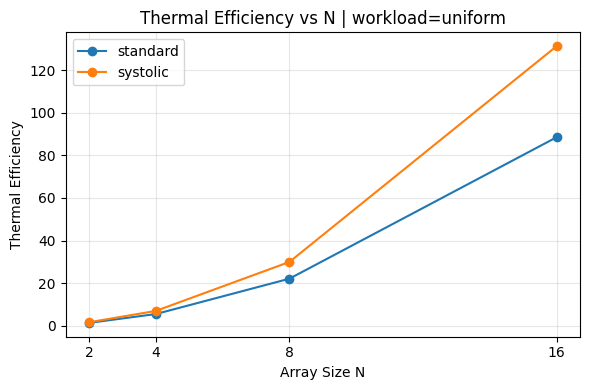

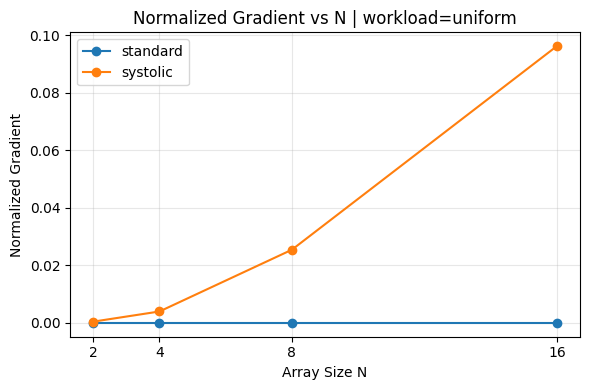

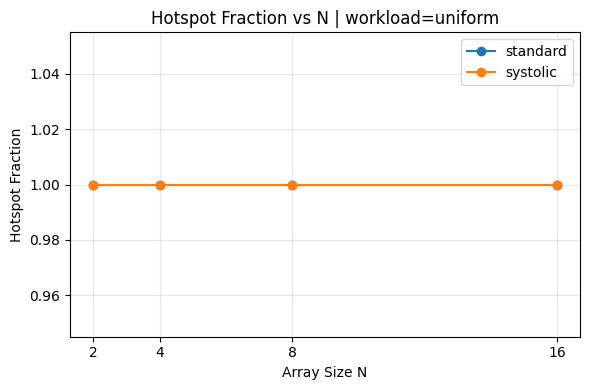

In [16]:
def architecture_metric_plot(workload, metric, ylabel, filename_suffix):
    sub = thermal_metrics_df[thermal_metrics_df["workload"] == workload].sort_values(["architecture", "N"])

    plt.figure(figsize=(6, 4))
    for arch in sorted(sub["architecture"].unique()):
        arch_df = sub[sub["architecture"] == arch].sort_values("N")
        plt.plot(arch_df["N"], arch_df[metric], marker="o", label=arch)

    plt.title(f"{ylabel} vs N | workload={workload}")
    plt.xlabel("Array Size N")
    plt.ylabel(ylabel)
    plt.xticks(sorted(sub["N"].unique()))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(advanced_plot_dir / f"{metric}_{filename_suffix}_{workload}.png", dpi=200, bbox_inches="tight")
    plt.show()


for wl in sorted(thermal_metrics_df["workload"].unique()):
    architecture_metric_plot(wl, "thermal_efficiency", "Thermal Efficiency", "arch_compare")
    architecture_metric_plot(wl, "grad_norm", "Normalized Gradient", "arch_compare")
    architecture_metric_plot(wl, "hotspot_fraction", "Hotspot Fraction", "arch_compare")

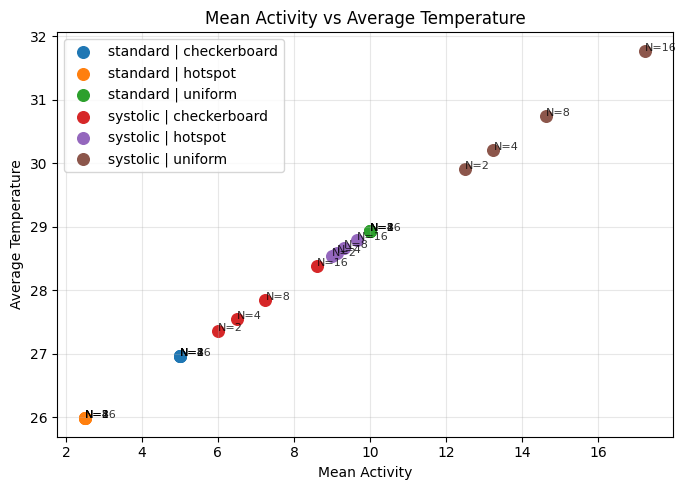

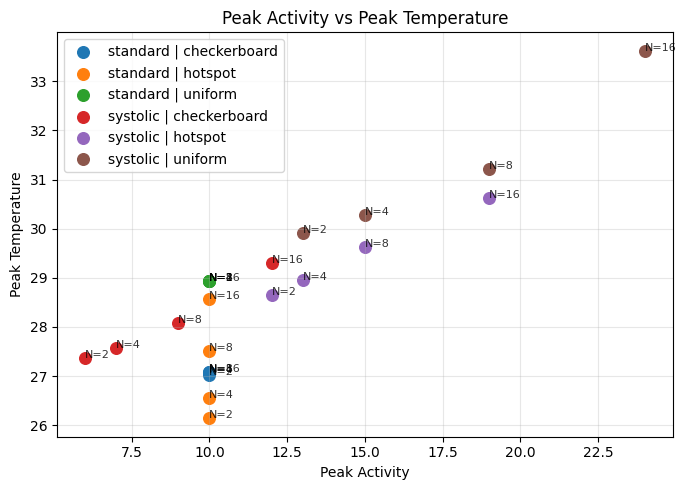

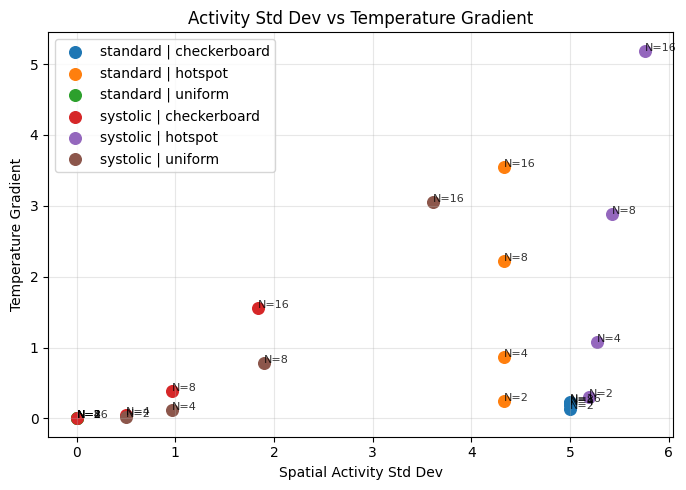

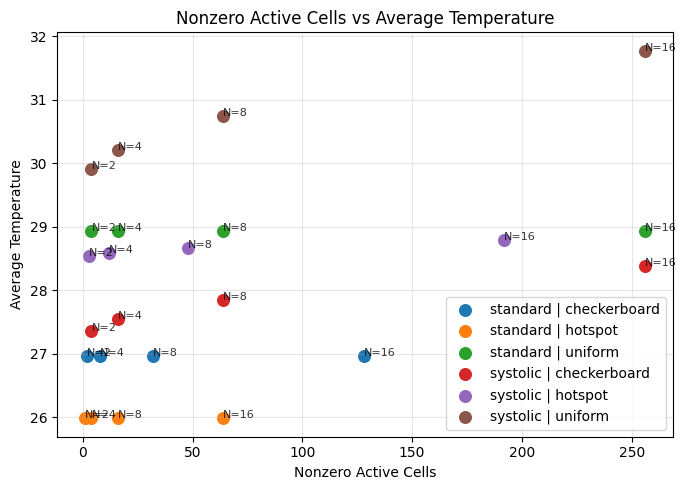

In [17]:
insight_plot_dir = THERMAL_DIR / "architecture_insight_plots"
insight_plot_dir.mkdir(parents=True, exist_ok=True)

def scatter_by_arch_workload(df, x_col, y_col, title, xlabel, ylabel, filename):
    plt.figure(figsize=(7, 5))

    for arch in sorted(df["architecture"].unique()):
        for workload in sorted(df["workload"].unique()):
            sub = df[(df["architecture"] == arch) & (df["workload"] == workload)]
            plt.scatter(sub[x_col], sub[y_col], s=70, label=f"{arch} | {workload}")

            for _, row in sub.iterrows():
                plt.annotate(f"N={int(row['N'])}", (row[x_col], row[y_col]), fontsize=8, alpha=0.8)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(insight_plot_dir / filename, dpi=200, bbox_inches="tight")
    plt.show()


scatter_by_arch_workload(
    thermal_metrics_df,
    "mean_activity",
    "avg_temp",
    "Mean Activity vs Average Temperature",
    "Mean Activity",
    "Average Temperature",
    "mean_activity_vs_avg_temp.png"
)

scatter_by_arch_workload(
    thermal_metrics_df,
    "max_activity",
    "peak_temp",
    "Peak Activity vs Peak Temperature",
    "Peak Activity",
    "Peak Temperature",
    "max_activity_vs_peak_temp.png"
)

scatter_by_arch_workload(
    thermal_metrics_df,
    "std_activity",
    "temp_gradient",
    "Activity Std Dev vs Temperature Gradient",
    "Spatial Activity Std Dev",
    "Temperature Gradient",
    "std_activity_vs_temp_gradient.png"
)

scatter_by_arch_workload(
    thermal_metrics_df,
    "nonzero_cells",
    "avg_temp",
    "Nonzero Active Cells vs Average Temperature",
    "Nonzero Active Cells",
    "Average Temperature",
    "nonzero_cells_vs_avg_temp.png"
)

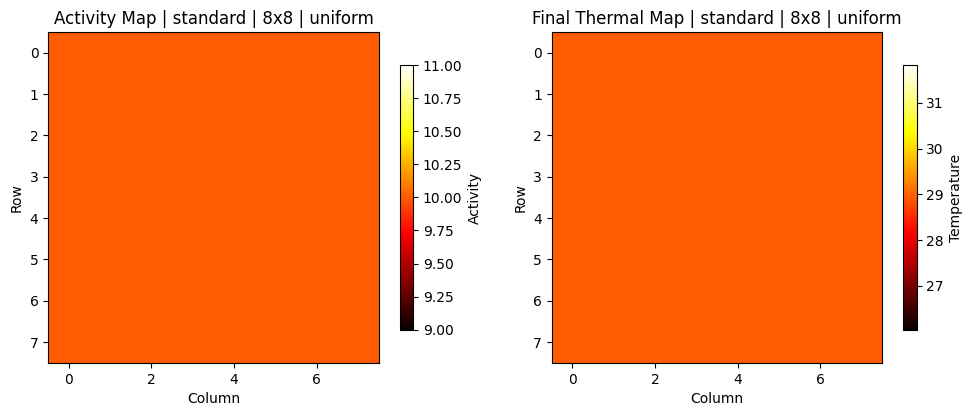

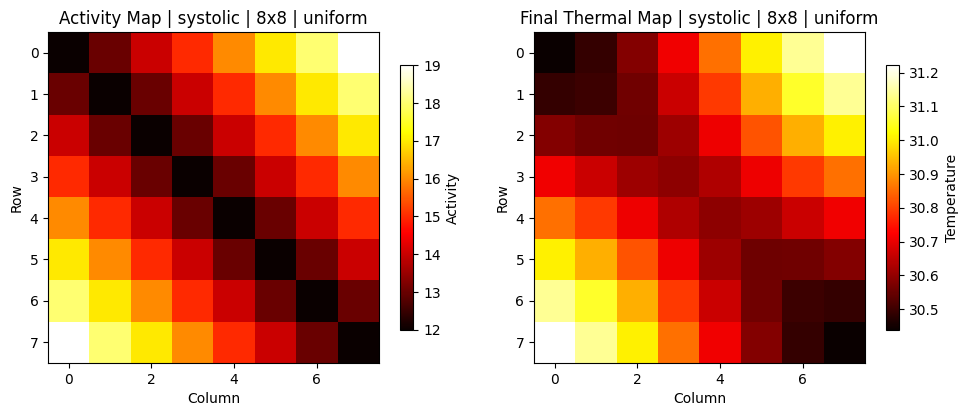

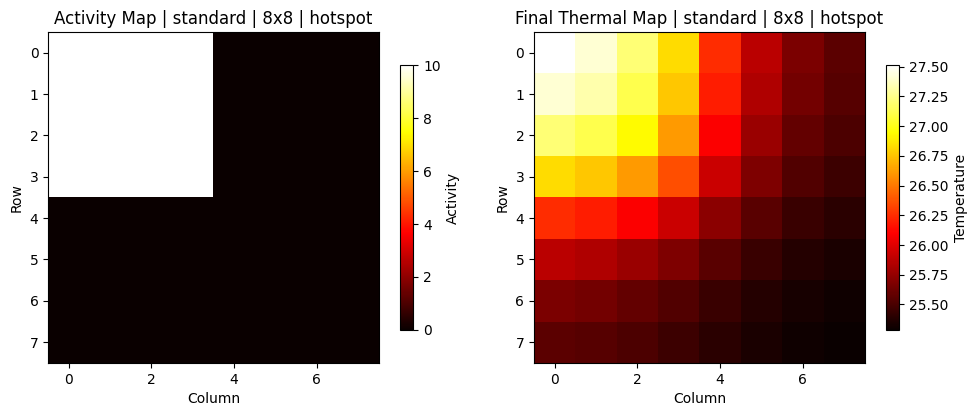

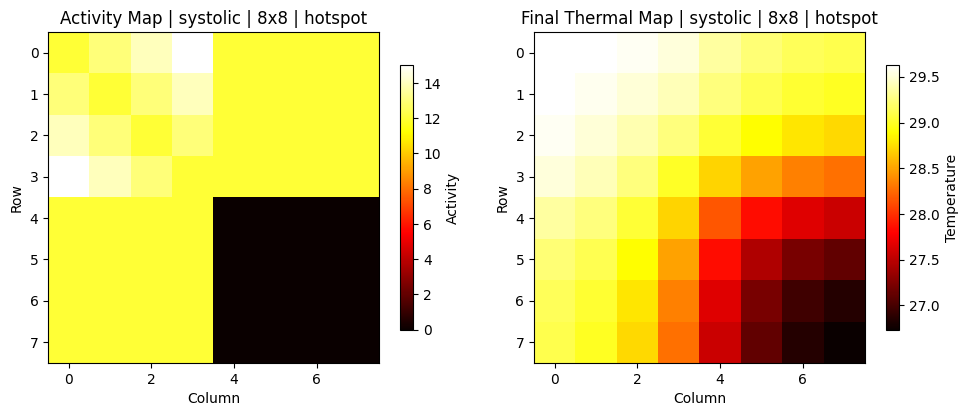

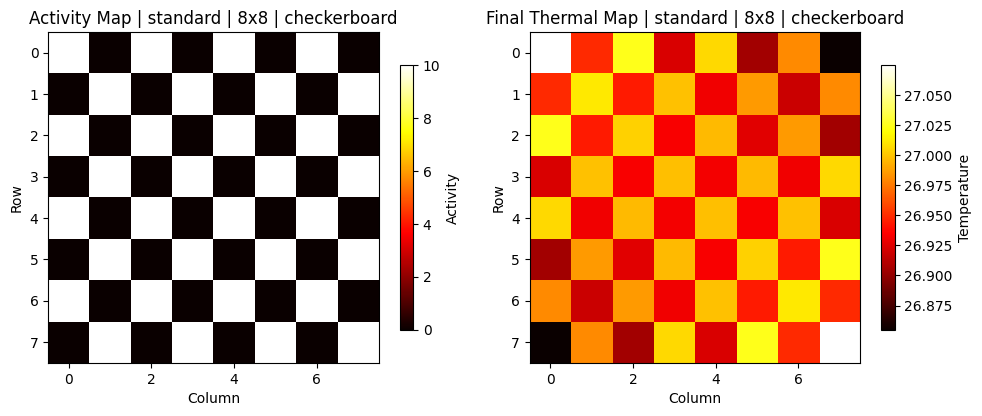

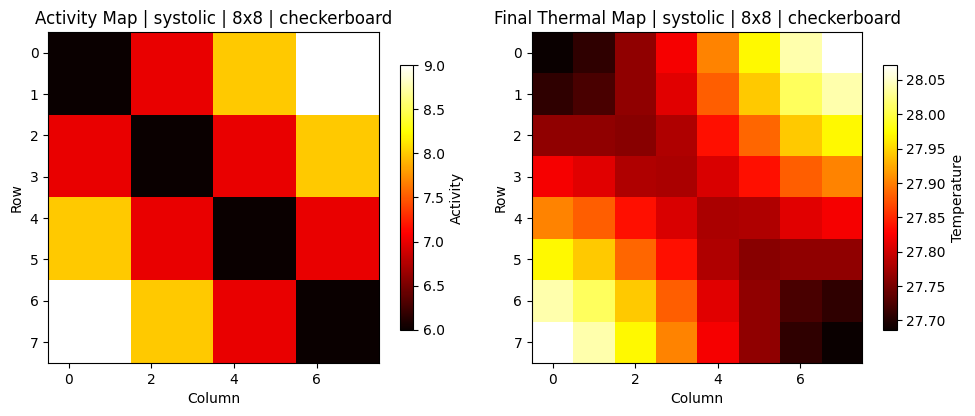

In [18]:
def plot_activity_to_temperature_comparison(architecture, N, workload, cmap_activity="hot", cmap_temp="hot"):
    key = (architecture, N, workload)

    A = all_activity_matrices[key]
    T = all_final_temperature_maps[key]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(A, interpolation="nearest", cmap=cmap_activity)
    axes[0].set_title(f"Activity Map | {architecture} | {N}x{N} | {workload}")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Row")
    fig.colorbar(im0, ax=axes[0], shrink=0.8, label="Activity")

    im1 = axes[1].imshow(T, interpolation="nearest", cmap=cmap_temp)
    axes[1].set_title(f"Final Thermal Map | {architecture} | {N}x{N} | {workload}")
    axes[1].set_xlabel("Column")
    axes[1].set_ylabel("Row")
    fig.colorbar(im1, ax=axes[1], shrink=0.8, label="Temperature")

    plt.tight_layout()
    plt.show()


# Recommended comparisons
plot_activity_to_temperature_comparison("standard", 8, "uniform")
plot_activity_to_temperature_comparison("systolic", 8, "uniform")

plot_activity_to_temperature_comparison("standard", 8, "hotspot")
plot_activity_to_temperature_comparison("systolic", 8, "hotspot")

plot_activity_to_temperature_comparison("standard", 8, "checkerboard")
plot_activity_to_temperature_comparison("systolic", 8, "checkerboard")